In [1]:
!pip install --no-index seaborn
!pip install --no-index networkx

Looking in links: /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/x86-64-v3, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/generic, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/generic
Looking in links: /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/x86-64-v3, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/generic, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/generic


In [1]:
import gzip
import numpy as np
import pandas as pd
import scipy
from itertools import combinations
import networkx as nx
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
hla_vcf = '../data/1000G/HLA_typed/EUR.qc.no_monomorphic.vcf.gz'

In [3]:
# Load HLA allele matrix

header = None
samples = None

with gzip.open(hla_vcf, 'rt') as ifile:
    for line in ifile:
        if line.startswith("#CHROM"):
            header = line.rstrip().split('\t')
            assert len(header) > 9
            samples = header[9:]
            break

assert header is not None
assert samples is not None and len(samples) > 0

rows = []
for sample in samples:
    rows.append(dict())

with gzip.open(hla_vcf, 'rt') as ifile:
    for line in ifile:
        if line.startswith('#'): continue
        fields = dict(zip(header, line.rstrip().split('\t')))
        allele = fields['ID'].removeprefix('HLA-')

        # Keep only classical Class I and Class II
        if allele.split('*')[0] not in {'A', 'B', 'C', 'DPA1', 'DPB1', 'DQB1', 'DRA', 'DRB1'}: continue
        
        format_field = fields['FORMAT'].split(':')
        for i, sample in enumerate(samples):
            sample_field = dict(zip(format_field, fields[sample].split(':')))
            gt = sample_field['GT']
            if gt == './.':
                gt = np.nan
            else:
                gt = sum(float(x) for x in gt.split('/'))
            rows[i][allele] = gt
        
hla_df = pd.DataFrame(rows)

# check if no monomorphic
assert all(hla_df.var() > 0) 

# Remove alleles with MAC < 5
mac = hla_df.sum(axis=0)
hla_df = hla_df.loc[:, mac >= 5]

In [5]:
# correlation matrix
corr = hla_df.corr(method = "pearson")

# correlation matrix should have no NAs
assert corr.isna().sum().sum() == 0

print (corr.shape)

(133, 133)


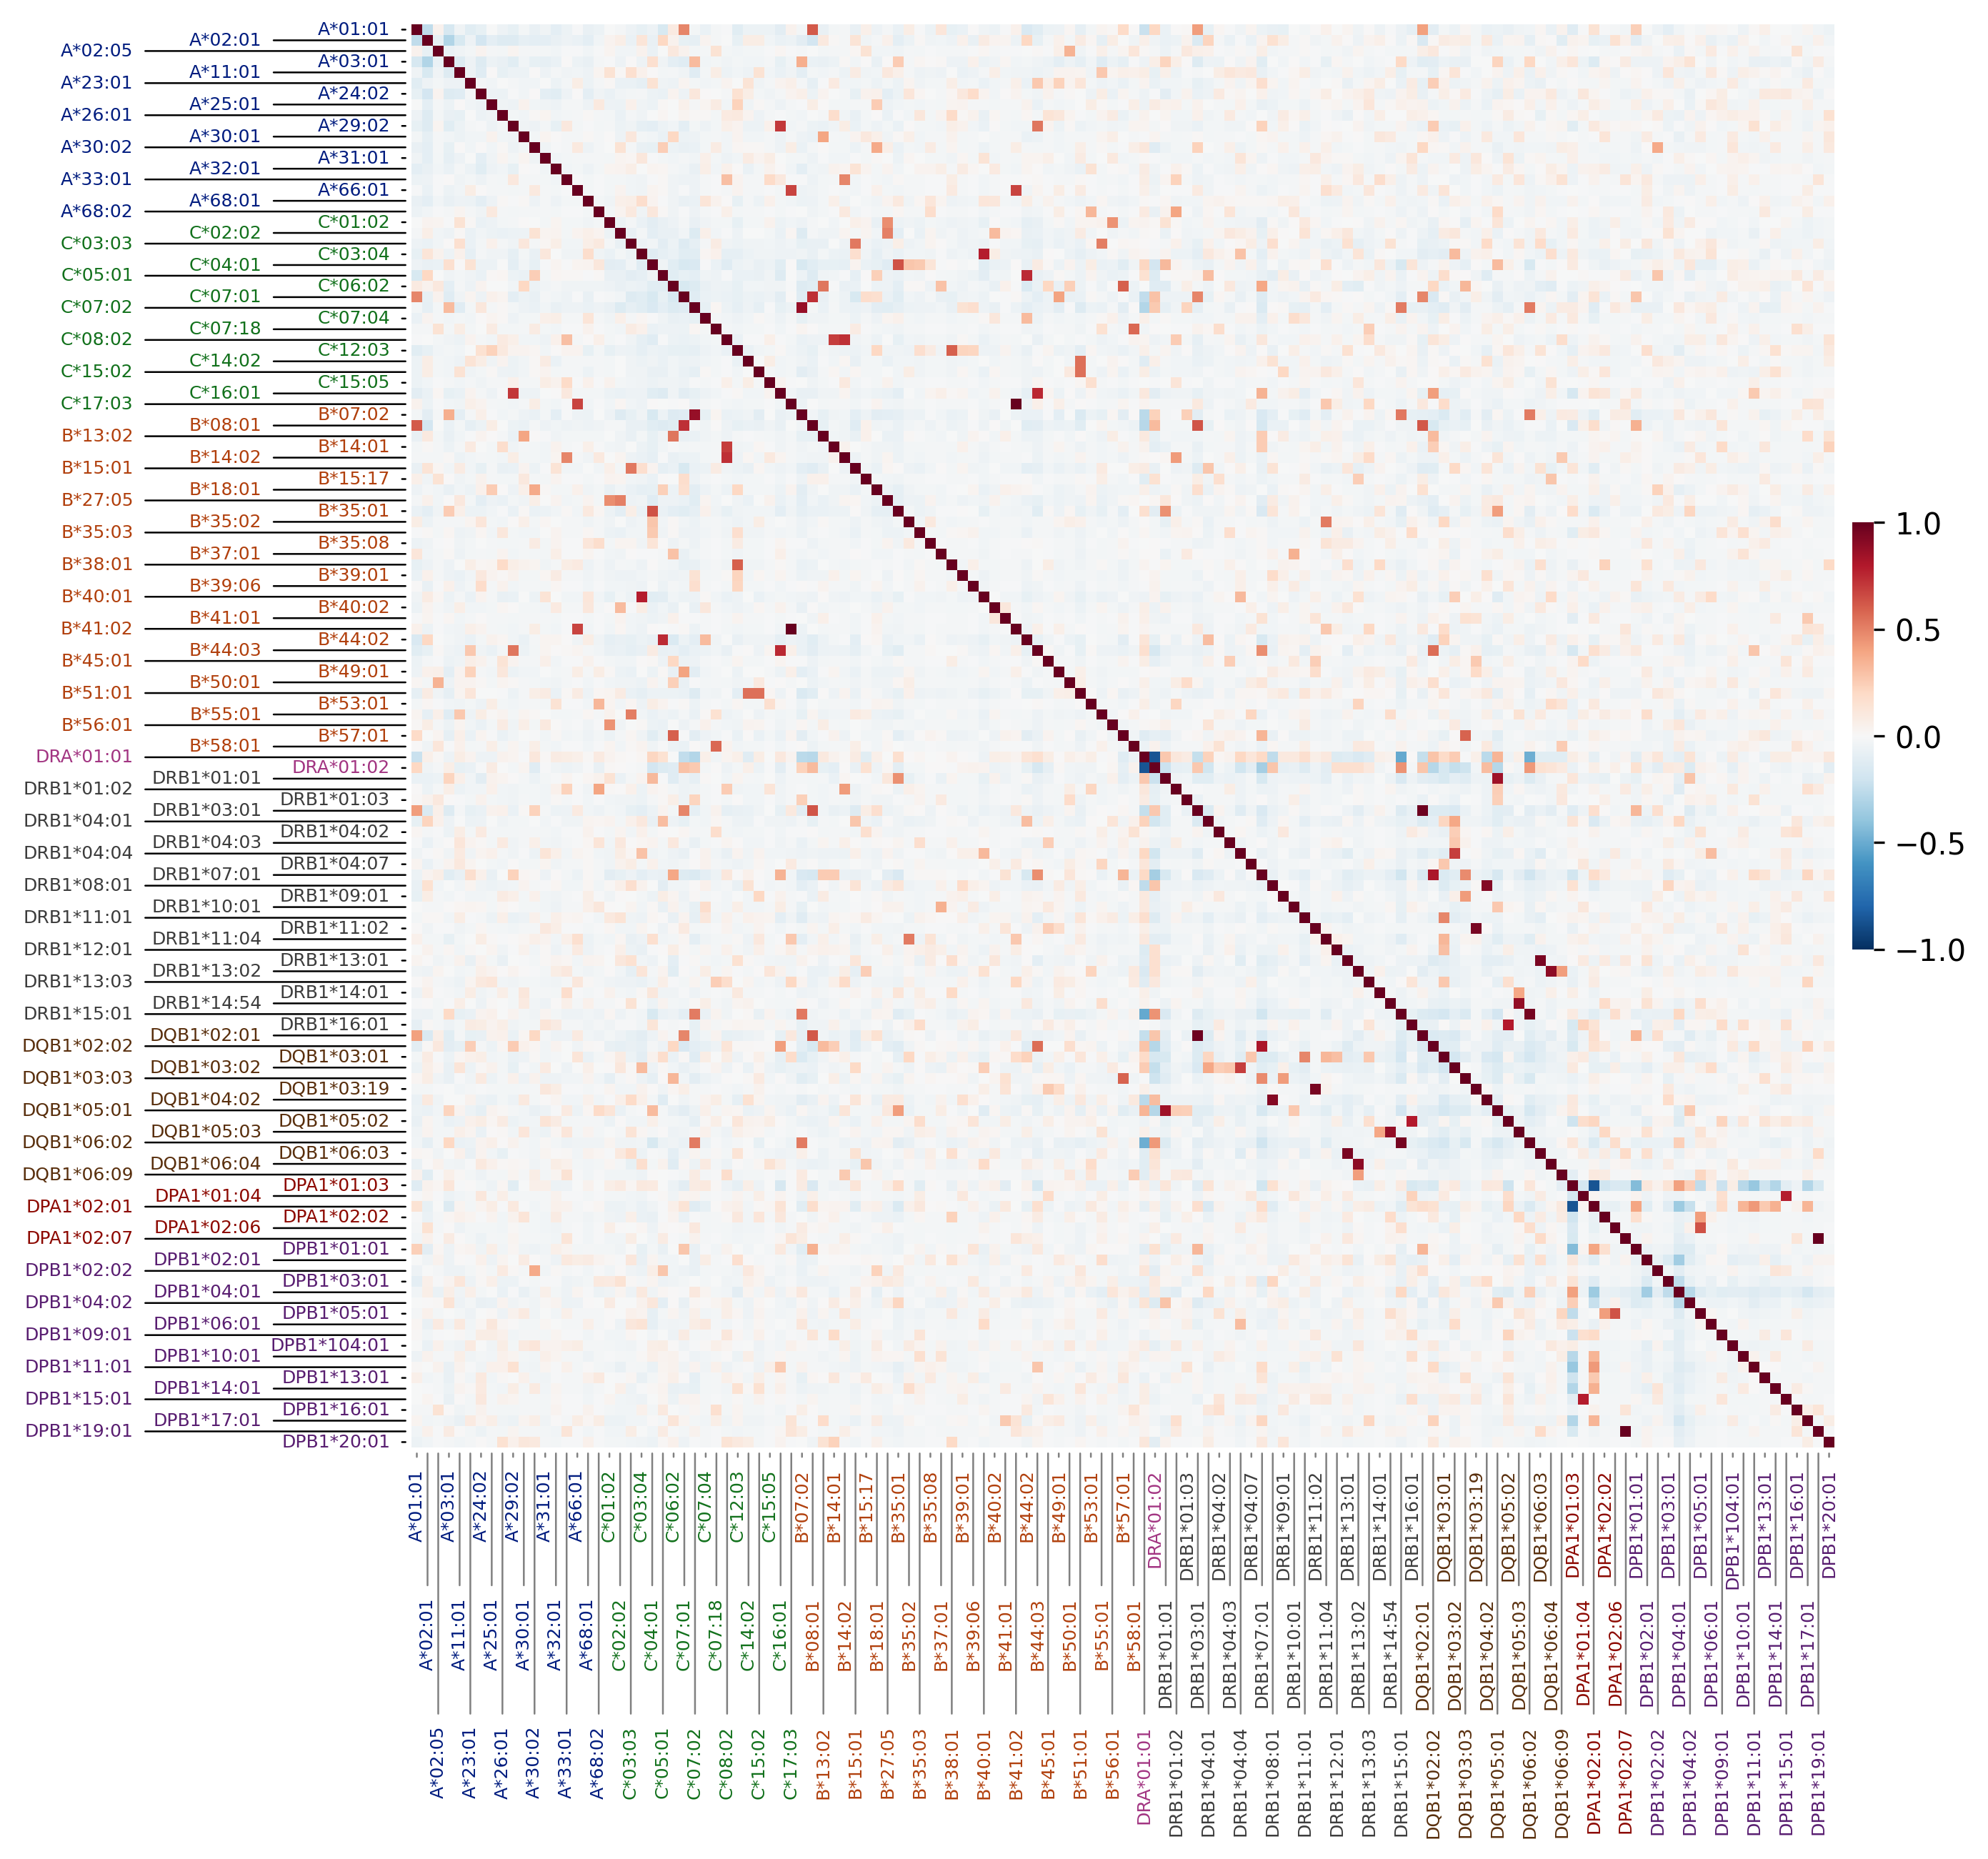

In [6]:
fig, ax = plt.subplots(figsize = (10, 8), dpi = 300)

sns.heatmap(
    corr, 
    cmap = "RdBu_r",
    center = 0,
    vmin = -1,
    vmax = 1,
    square = True, 
    cbar_kws = {"shrink": 0.3, "pad": 0.01},
    ax = ax,
    xticklabels = False, 
    yticklabels=False
)

axis_label_offsets = [2, 14, 26] 


genes = sorted(set([c.split("*")[0] for c in corr.columns]))
gene_color = dict(zip(genes, sns.color_palette("dark", len(genes))))

for i, label in enumerate(corr.columns):
    offset_x = -1 * axis_label_offsets[i % 3]
    ax.annotate(
        label, 
        xy = (0, i + 0.5),          # Point exactly to the middle of the cell/tick
        xytext = (offset_x, i + 0.5), # Offset the text to the left
        va = 'center', 
        ha = 'right', 
        color = gene_color[label.split('*')[0]],
        fontsize = 6,
        arrowprops = dict(arrowstyle = "-", color = "black", lw = 0.6)
    )

for i, label in enumerate(corr.columns):
    offset_y = axis_label_offsets[i % 3]
    ax.annotate(
        label, 
        xy = (i + 0.5, 133),         # Point exactly to the bottom edge of the cell/tick
        xytext = (i + 0.5, 133 + offset_y), # Offset the text downwards
        va = 'top', 
        ha = 'center', 
        rotation = 90,
        color = gene_color[label.split('*')[0]],
        fontsize = 6,
        arrowprops = dict(arrowstyle = "-", color = "grey", lw = 0.6)
    )

# Tight layout adjustments to prevent the offset text from clipping out of the final image
plt.subplots_adjust(left = 0.15, bottom = 0.15, right = 0.98, top = 0.98)
plt.show()


/localscratch/dtaliun.65391299.0/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/localscratch/dtaliun.65391299.0/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


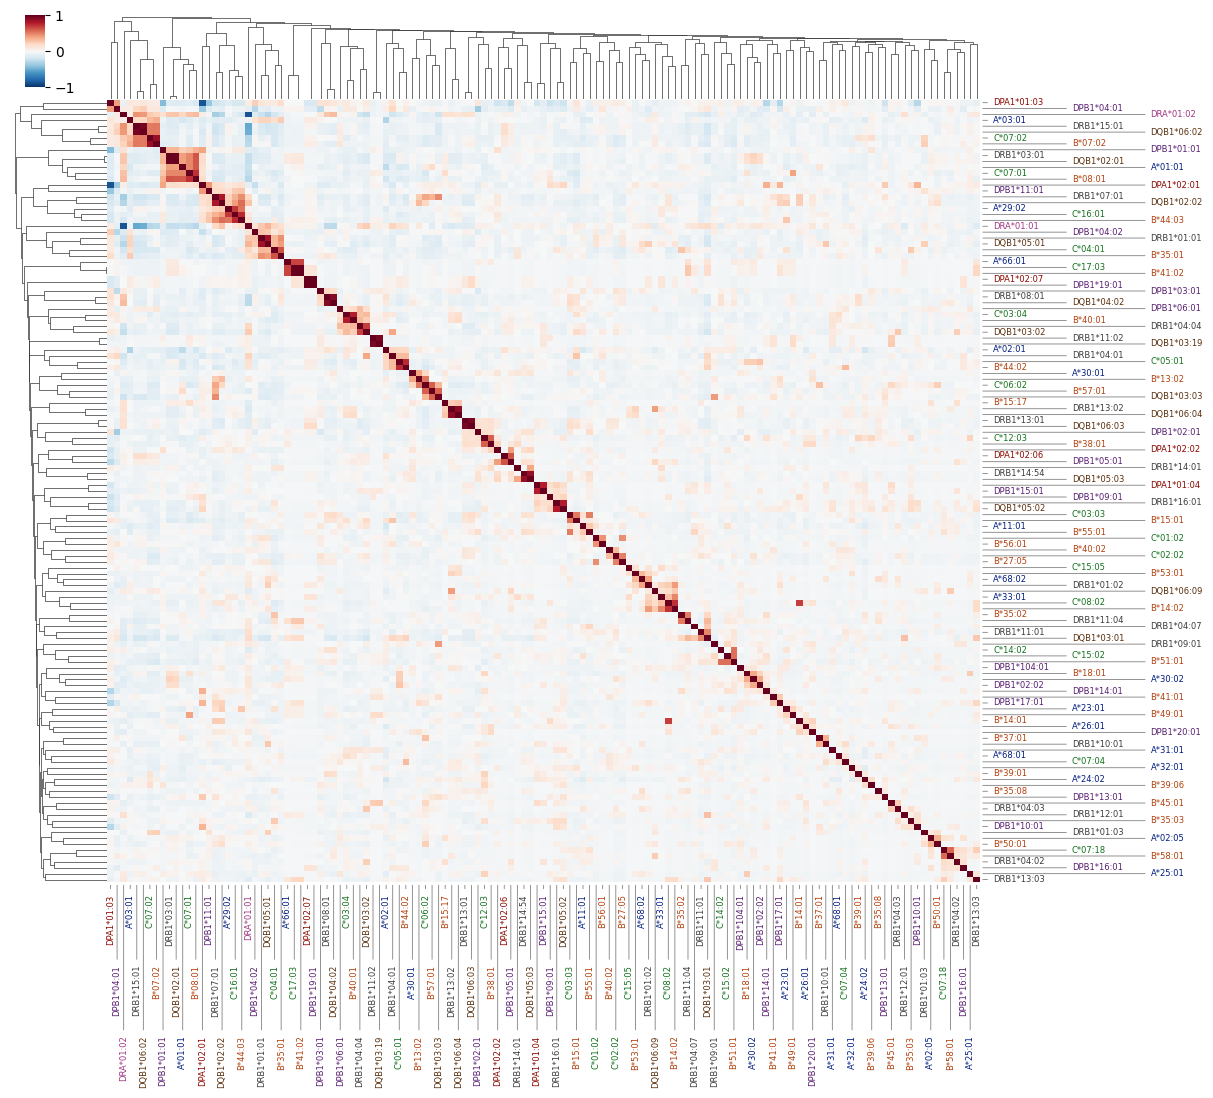

In [7]:
g = sns.clustermap(
    corr,
    figsize = (10, 9), 
    cmap = "RdBu_r",
    center = 0,
    vmin = -1,
    vmax = 1,

    # cbar_pos=(0.02, 0.85, 0.02, 0.08) 
    cbar_pos=(0.03, 0.90, 0.02, 0.08),
    
    # cbar_kws = {"shrink": 0.1, "pad": 0.01},
    xticklabels = False, 
    yticklabels = False,
    linewidths = 0,
    dendrogram_ratio = 0.1
)

# Extract the heatmap axis and dimensions
ax = g.ax_heatmap
n_rows, n_cols = corr.shape

# Setup color mapping based on original labels
axis_label_offsets = [2, 14, 26] 
genes = sorted(set([c.split("*")[0] for c in corr.columns]))
gene_color = dict(zip(genes, sns.color_palette("dark", len(genes))))

# 2. Get the new clustered order of your rows and columns
row_order = g.dendrogram_row.reordered_ind
col_order = g.dendrogram_col.reordered_ind

# 3. Apply Y-Axis (Row) Annotations using the clustered order
for visual_idx, original_idx in enumerate(row_order):
    label = corr.index[original_idx]
    offset_x = axis_label_offsets[visual_idx % 3]
    
    ax.annotate(
        label, 
        xy=(n_cols, visual_idx + 0.5),          
        xytext=(n_cols + offset_x, visual_idx + 0.5), 
        va='center', 
        ha='left', 
        color=gene_color[label.split('*')[0]],
        fontsize=6,
        arrowprops=dict(arrowstyle="-", color="grey", lw=0.6)
    )

# 4. Apply X-Axis (Column) Annotations using the clustered order
for visual_idx, original_idx in enumerate(col_order):
    label = corr.columns[original_idx]
    offset_y = axis_label_offsets[visual_idx % 3]
    
    ax.annotate(
        label, 
        xy=(visual_idx + 0.5, n_rows),         
        xytext=(visual_idx + 0.5, n_rows + offset_y), 
        va='top', 
        ha='center', 
        rotation=90,
        color=gene_color[label.split('*')[0]],
        fontsize=6,
        arrowprops=dict(arrowstyle="-", color="grey", lw=0.6)
    )

In [8]:
# Compute Eigenvalues
eigvals = np.linalg.eigvalsh(corr)
eigvals = np.sort(eigvals)[::-1]

51


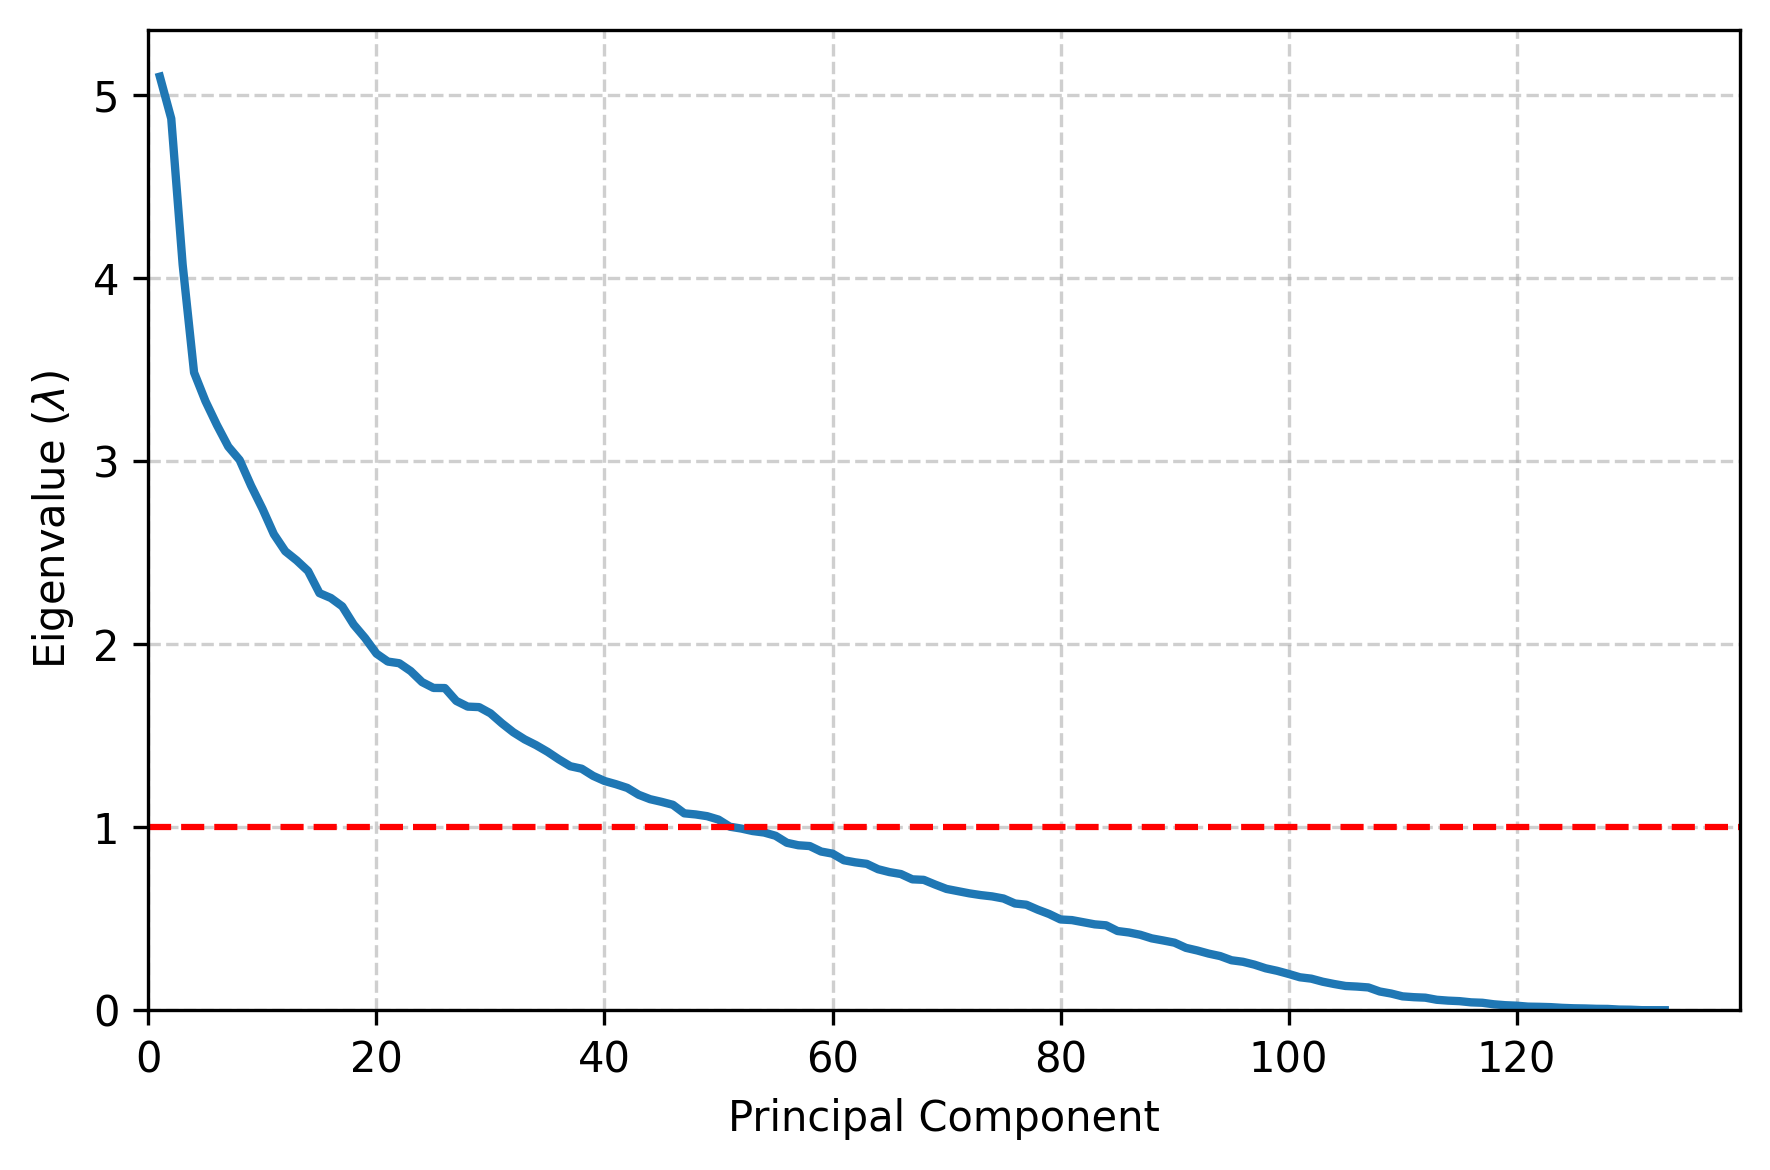

In [9]:
# Cite Scree plot: Cattell, R. B. (1966). The scree test for the number of factors. Multivariate Behavioral Research, 1(2), 245–276.
# Cite Kaiser Criterion Line: Kaiser, H. F. (1960). The application of electronic computers to factor analysis. Educational and Psychological Measurement, 20(1), 141–151.

print(sum(eigvals > 1))

fig, ax = plt.subplots(figsize = (6, 4), dpi = 300)

ax.plot(
    np.arange(1, len(eigvals)+1),
    eigvals,
    linewidth = 2,
)

ax.grid(True, which='major', axis='both', linestyle='--', alpha=0.6)

# 
ax.axhline(
    y = 1,
    color = 'red',
    linestyle = '--',
    linewidth = 1.5,
)

ax.set_xlabel('Principal Component')
ax.set_ylabel(r'Eigenvalue ($\lambda$)')

ax.set_ylim(bottom = 0)
ax.set_xlim(left = 0)

plt.tight_layout()
plt.show()

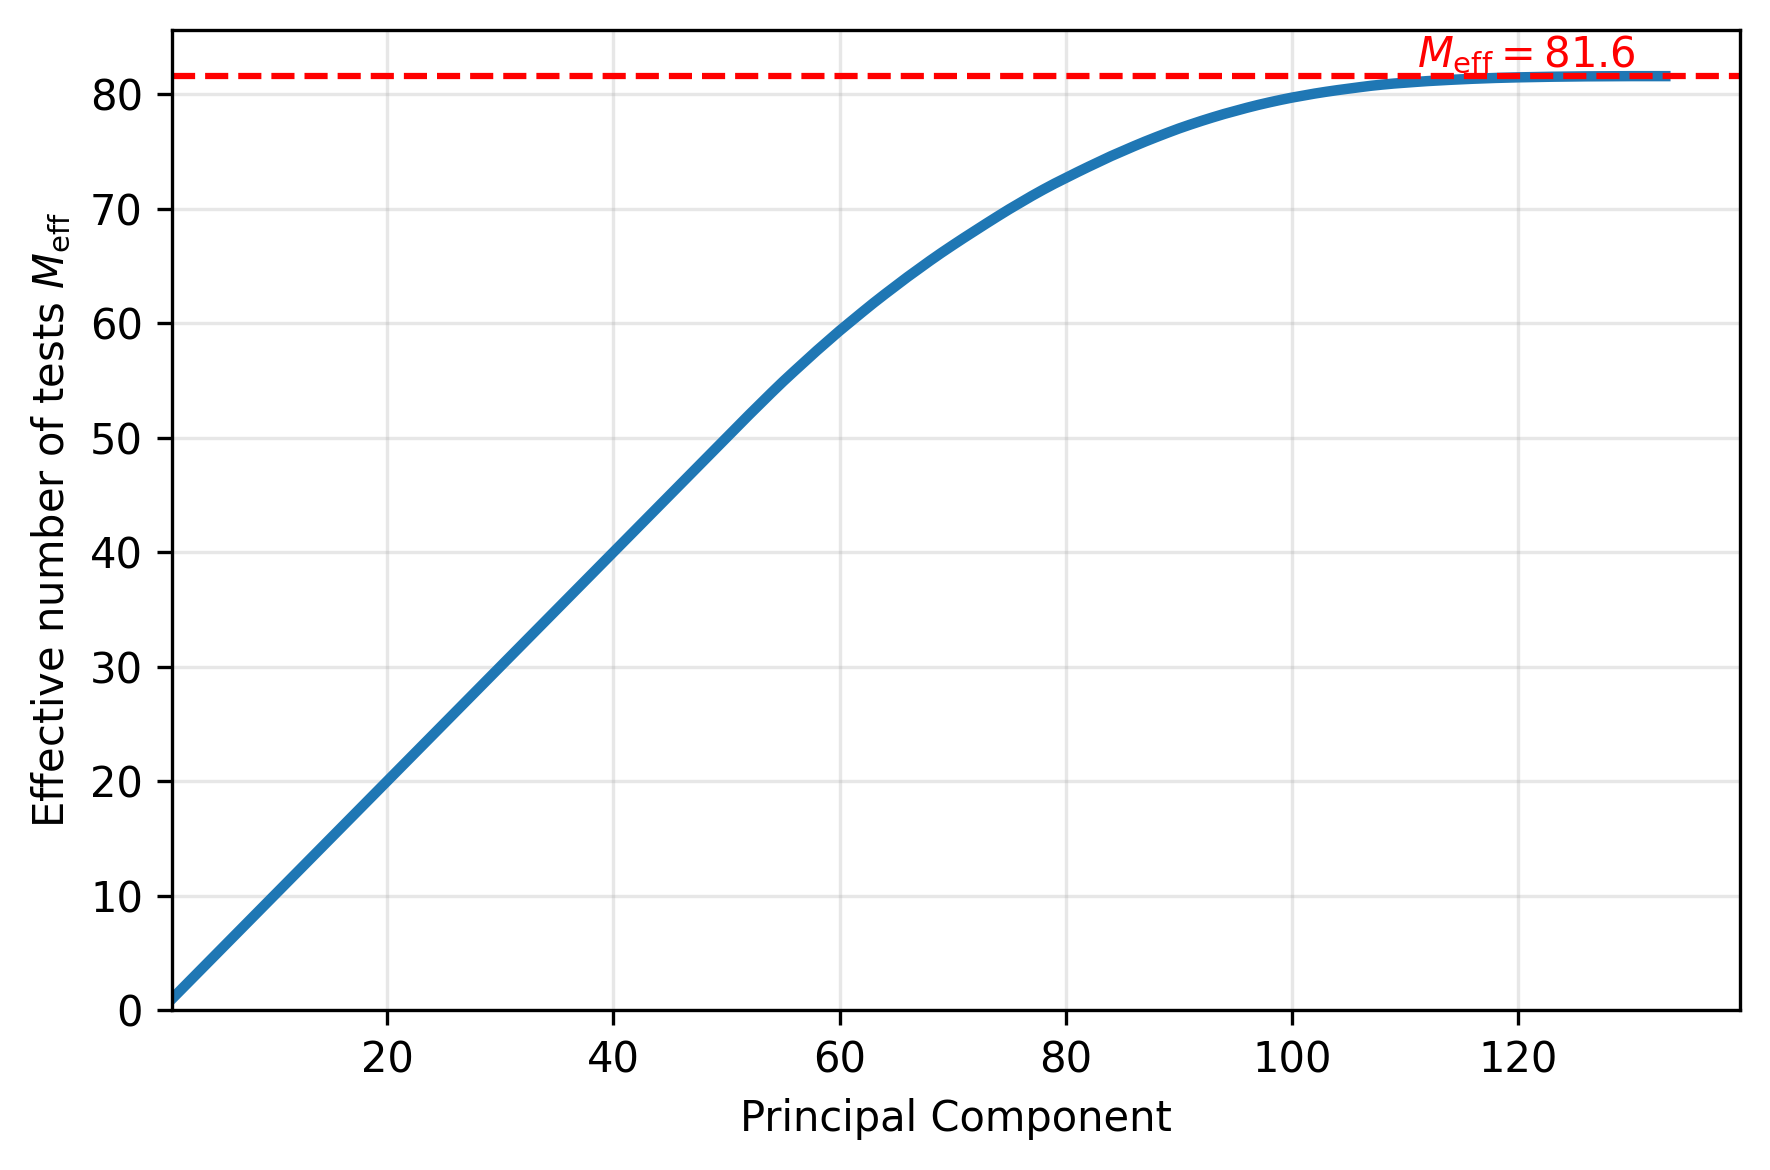

In [10]:
# Cite: Li, J., & Ji, L. (2005). Adjusting multiple testing in multilocus analyses using the eigenvalues of a correlation matrix. Behavior Genetics, 35(2), 221–227

fig, ax = plt.subplots(figsize = (6, 4), dpi = 300)

li_ji_contrib = np.minimum(eigvals, 1)
cum_meff = np.cumsum(li_ji_contrib)

ax.plot(
    np.arange(1, len(eigvals)+1),
    cum_meff,
    linewidth=2.5,
    color='C0'
)

final_meff = cum_meff[-1]

ax.axhline(
    final_meff,
    color='red',
    linestyle='--',
    linewidth=1.5
)

ax.text(
    0.98 * len(eigvals),
    final_meff,
    fr'$M_{{\rm eff}} = {final_meff:.1f}$',
    color='red',
    ha='right',
    va='bottom'
)

ax.grid(True, which='major', alpha=0.3)

ax.set_xlim(left = 1)
ax.set_ylim(bottom = 0)

ax.set_xlabel('Principal Component')
ax.set_ylabel(r'Effective number of tests $M_{\rm eff}$')

plt.tight_layout()
plt.show()

In [11]:
# Collect correlation coefficient for alleles within the same gene and alleles between different genes.
within = []
between = []

for allele1, allele2 in combinations(corr.columns, 2):
    r = corr.loc[allele1, allele2]
    assert not pd.isna(r) # We made sure that there are no NAs in the correlation matrix because of MAC >= 5
    gene1 = allele1.split('*')[0]
    gene2 = allele2.split('*')[0]
    if gene1 == gene2:
        within.append(r)
    else:
        between.append(r)

within = np.array(within)
between = np.array(between)

/tmp/ipykernel_934101/169990788.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([


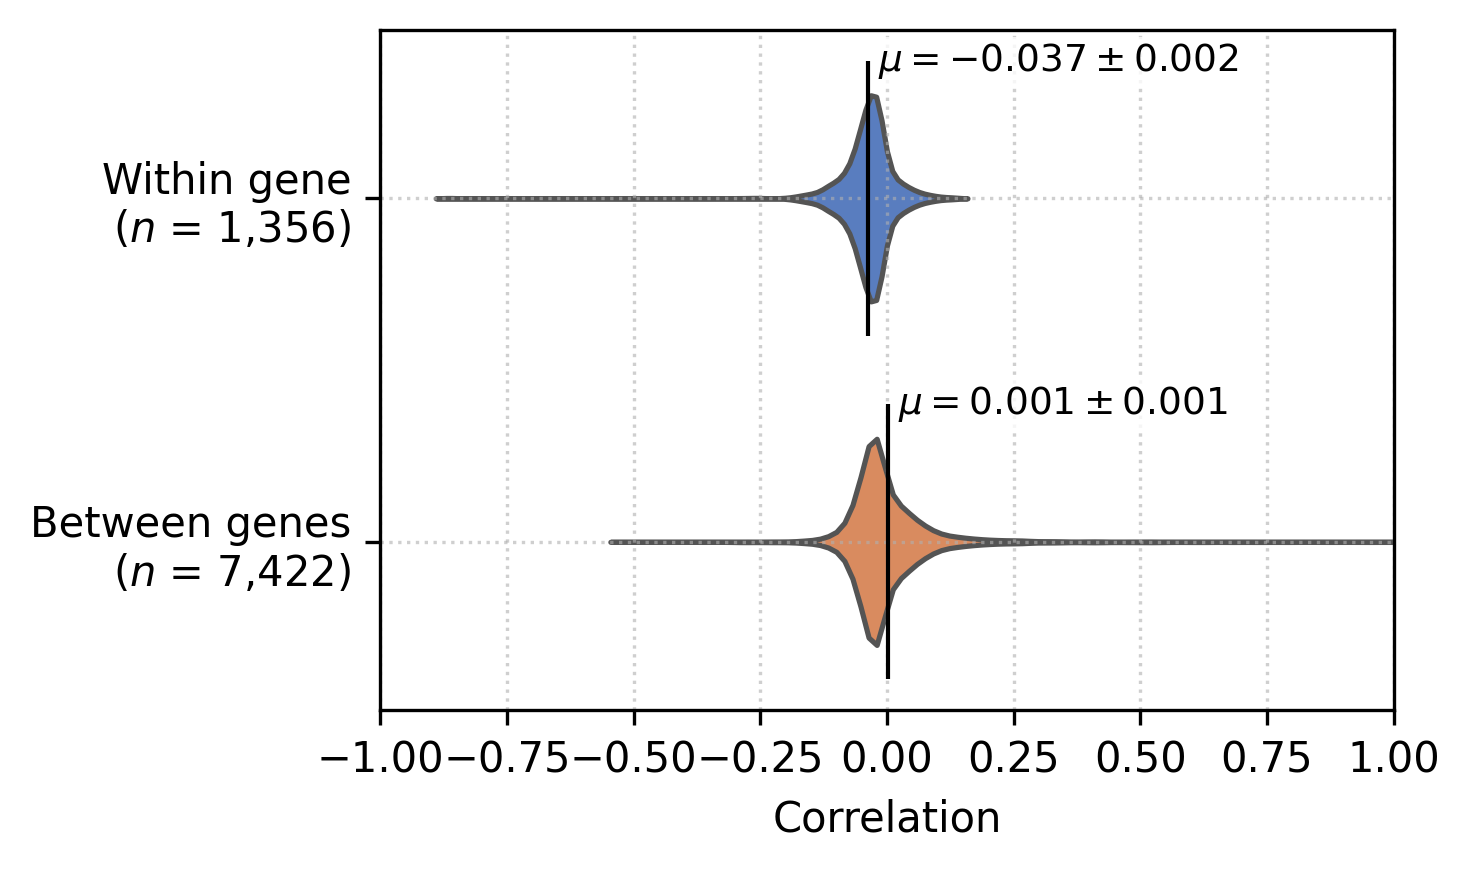

In [12]:
fig, ax = plt.subplots(figsize = (5, 3), dpi = 300)

plot_df = pd.DataFrame({
    "Correlation": np.concatenate([within, between]),
    "Type": (["Within gene"] * len(within)) +
            (["Between genes"] * len(between))
})

violinplot_order = ['Within gene', 'Between genes']

sns.violinplot(
    ax = ax,
    data = plot_df,
    x = "Correlation",
    y = "Type",
    hue = "Type",
    order = violinplot_order,
    inner = None,
    palette = "muted",
    width = 0.6,
    legend = False
)

stats = plot_df.groupby("Type")["Correlation"].agg(["mean", "sem"])
for i, category in enumerate(violinplot_order):
    mean_val = stats.loc[category, "mean"]
    se_val = stats.loc[category, "sem"]
    ax.vlines(x = mean_val, ymin = i - 0.4, ymax = i + 0.4, color = "black", linewidths = 1, linestyle = '-')

    ax.text(
        x = mean_val + 0.02, 
        y = i - 0.4,
        s=f"$\mu = {mean_val:.3f} \pm {se_val:.3f}$",
        color = "black",
        weight = "bold",
        ha = "left", 
        va = "center",
        fontsize = 9,
        bbox = dict(facecolor = 'white', alpha = 0.8, edgecolor = 'none', pad = 1)
    )


ax.set_xlim(-1, 1)

ax.grid(True, linestyle = ":", alpha = 0.6, zorder = 0)
ax.set_ylabel(None)

ax.set_yticklabels([
    f"Within gene\n($n$ = {len(within):,})", 
    f"Between genes\n($n$ = {len(between):,})"
])

plt.tight_layout()
plt.show()

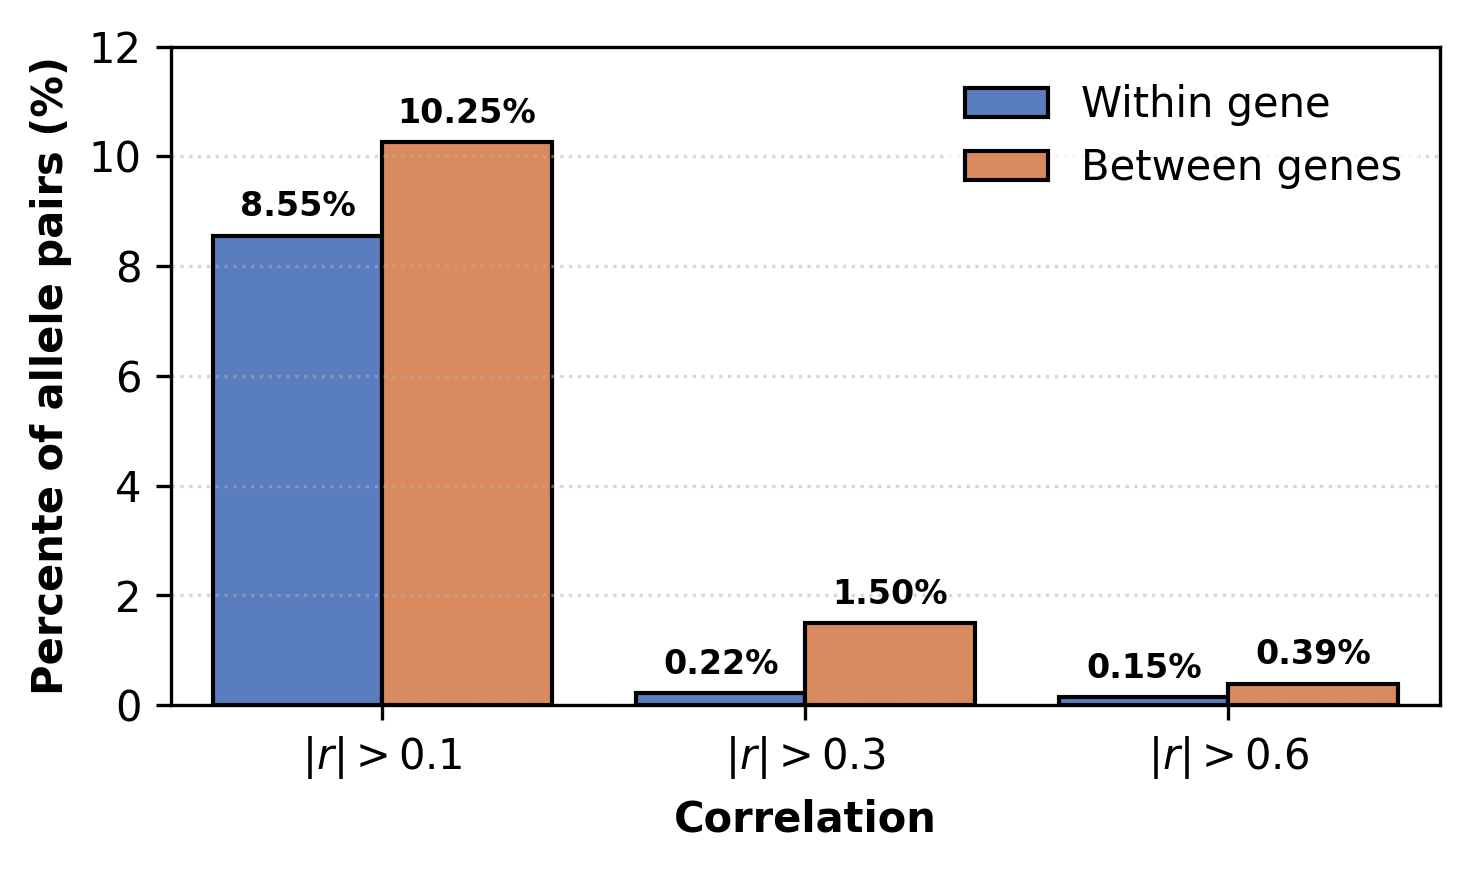

In [13]:
fig, ax = plt.subplots(figsize = (5, 3), dpi = 300)

thresholds = [0.1, 0.3, 0.6]

plot_df = []
for t in thresholds:
    within_pct = ((np.abs(within) > t).sum() / len(within)) * 100
    between_pct = ((np.abs(between) > t).sum() / len(between)) * 100
    plot_df.append({"Threshold": f"$|r| > {t}$", "Type": "Within gene", "Percentage": within_pct})
    plot_df.append({"Threshold": f"$|r| > {t}$", "Type": "Between genes", "Percentage": between_pct})
plot_df = pd.DataFrame(plot_df)

sns.barplot(
    ax = ax,
    data = plot_df,
    x = "Threshold",
    y = "Percentage",
    hue = "Type",
    hue_order = ["Within gene", "Between genes"],
    palette = "muted",
    edgecolor = "black",
    linewidth = 1
)

for container in ax.containers:
    ax.bar_label(
        container, 
        fmt = "%.2f%%", 
        label_type = "edge", 
        padding = 3, 
        fontsize = 8, 
        fontweight = "bold"
    )

ax.set_ylabel("Percente of allele pairs (%)", fontsize = 10, fontweight = "bold")
ax.set_xlabel("Correlation", fontsize = 10, fontweight = "bold")


ax.grid(True, axis="y", linestyle=":", alpha=0.5, zorder=0)
ax.set_ylim(0, 12) 

plt.legend(loc = "upper right", frameon = True, facecolor = "white", edgecolor = "none")
plt.tight_layout()
plt.show()

In [14]:
# Print top strongest (r > 0.6) positive correlations
upper = corr.where(
    np.triu(np.ones(corr.shape), k = 1).astype(bool)
)
for (allele1, allele2), r  in upper.stack().sort_values(ascending = False).items():
    if r < 0.6:
        break
    ac1 = hla_df[allele1].sum()
    ac2 = hla_df[allele2].sum()
    print(f'{allele1}\t{allele2}\t{ac1:.0f}\t{ac2:.0f}\t{r:.2f}')

DPA1*02:07	DPB1*19:01	8	8	1.00
C*17:03	B*41:02	7	7	1.00
DRB1*03:01	DQB1*02:01	105	103	0.98
DRB1*15:01	DQB1*06:02	120	111	0.95
DRB1*11:02	DQB1*03:19	8	7	0.95
DRB1*13:01	DQB1*06:03	55	61	0.95
DRB1*08:01	DQB1*04:02	49	59	0.92
DRB1*13:02	DQB1*06:04	38	31	0.90
DRB1*14:54	DQB1*05:03	23	30	0.88
C*07:02	B*07:02	121	112	0.87
DRB1*01:01	DQB1*05:01	107	137	0.85
DRB1*07:01	DQB1*02:02	140	98	0.82
DRB1*16:01	DQB1*05:02	14	22	0.79
DPA1*01:04	DPB1*15:01	5	8	0.79
C*03:04	B*40:01	75	49	0.79
C*16:01	B*44:03	45	60	0.75
C*05:01	B*44:02	83	81	0.75
C*08:02	B*14:02	27	15	0.73
C*07:01	B*08:01	128	82	0.73
A*29:02	C*16:01	37	45	0.71
C*08:02	B*14:01	27	12	0.69
DRB1*04:04	DQB1*03:02	53	104	0.69
A*66:01	C*17:03	5	7	0.67
A*66:01	B*41:02	5	7	0.67
DPA1*02:06	DPB1*05:01	10	24	0.64
C*04:01	B*35:01	137	70	0.63
B*08:01	DRB1*03:01	82	105	0.63
B*08:01	DQB1*02:01	82	103	0.62
A*01:01	B*08:01	126	82	0.61


In [15]:
#disjoint subgraphs
alleles = corr.columns

for r_threshold in [0.3, 0.4, 0.5, 0.6]:
    G = nx.Graph()
    for i in range(len(alleles)):
        for j in range(i+1, len(alleles)):
            gene1 = alleles[i].split('*')[0]
            gene2 = alleles[j].split('*')[0]
            if gene1 == gene2: continue
            if abs(corr.iloc[i,j]) > r_threshold:
                G.add_edge(alleles[i], alleles[j])

    connected_components = list(nx.connected_components(G))
    n_connected_components = len(connected_components)
    
    n_alleles_per_component = []
    n_genes_per_component = []
    for c in connected_components:
        n_unique_alleles = len(c)
        n_unique_genes = len(set(allele.split('*')[0] for allele in c))
        n_alleles_per_component.append(n_unique_alleles)
        n_genes_per_component.append(n_unique_genes)
            
    min_connected_by_alleles = min(n_alleles_per_component)
    max_component_by_alleles = max(n_alleles_per_component)
    mean_component_by_alleles = np.mean(n_alleles_per_component)
    sem_component_by_alleles = scipy.stats.sem(n_alleles_per_component)

    min_connected_by_genes = min(n_genes_per_component)
    max_component_by_genes = max(n_genes_per_component)
    mean_component_by_genes = np.mean(n_genes_per_component)
    sem_component_by_genes = scipy.stats.sem(n_genes_per_component)

    
    print(f'By alleles:\t{r_threshold}\t{n_connected_components}\t[{min_connected_by_alleles},{max_component_by_alleles}]\t{mean_component_by_alleles:.2f} {sem_component_by_alleles:.2f}')
    print(f'By genes:\t{r_threshold}\t{n_connected_components}\t[{min_connected_by_genes},{max_component_by_genes}]\t{mean_component_by_genes:.2f} {sem_component_by_genes:.2f}')

By alleles:	0.3	21	[2,38]	4.86 1.70
By genes:	0.3	21	[2,8]	2.67 0.32
By alleles:	0.4	27	[2,10]	3.07 0.35
By genes:	0.4	27	[2,5]	2.52 0.20
By alleles:	0.5	26	[2,5]	2.58 0.20
By genes:	0.5	26	[2,5]	2.42 0.19
By alleles:	0.6	21	[2,5]	2.29 0.16
By genes:	0.6	21	[2,5]	2.24 0.15
